In [1]:
import Pkg
Pkg.activate("../..")

  Activating project at `~/.julia/dev/DiffusionEvolution`


In [2]:
using Revise

In [3]:
using DiffusionEvolution, PyPlot, LinearAlgebra, Statistics, JLD2

Precompiling DiffusionEvolution
  ✓ DiffusionEvolution
  1 dependency successfully precompiled in 3 seconds. 122 already precompiled.


In [4]:
const de = DiffusionEvolution

DiffusionEvolution

In [5]:
import PyPlot.subplots
subplots(x, y, d) = subplots(x, y, figsize=(y*d, x*d))

subplots (generic function with 2 methods)

In [6]:
d = 10
nsamples = 1000
T = 20

20

In [7]:
λ_diag = 0.1
λ_skew = 0.01
θ0 = fill(0.0, d)
θ1 = fill(5.0, d)
γ = 0.6
J, θ, min_eigv, max_eigv = random_pars(λ_diag, λ_skew, θ0, θ1, d=d);

In [8]:
min_eigv, max_eigv

(7.005483531333967, 14.72722195141802)

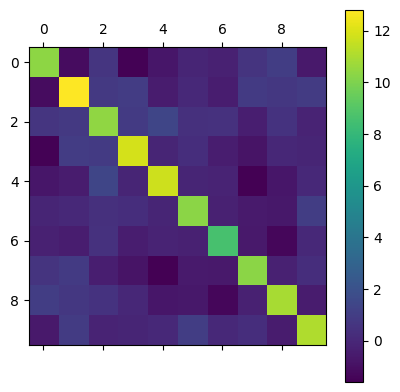

PyObject <matplotlib.colorbar.Colorbar object at 0x7a7f3a9f5f90>

In [9]:
matshow(inv(J))
colorbar()

In [10]:
θ |> norm

14.966143504258387

In [11]:
x = simulate_ou_process(J, θ, γ, nsamples=nsamples, T=T);

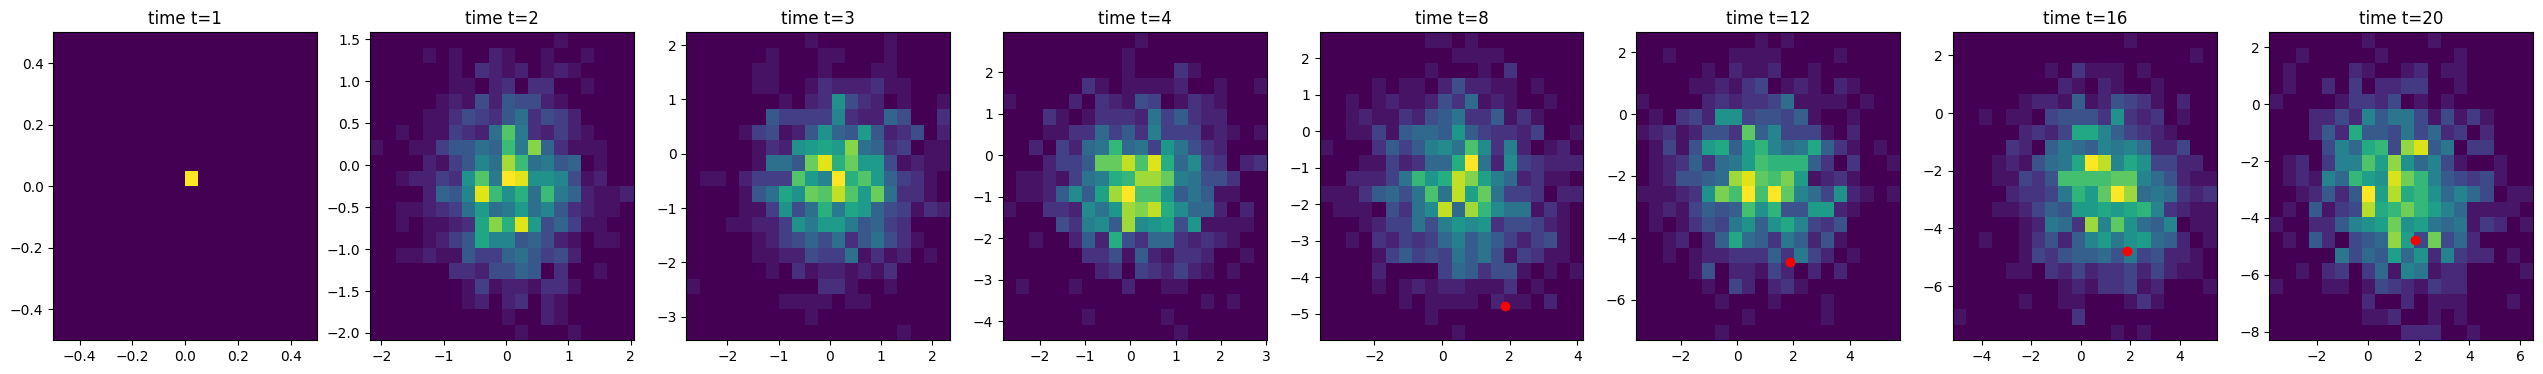

In [12]:
tpoints = [1,2,3,4,8,12,16,20]
fig, ax = subplots(1, length(tpoints), 4)
for t in eachindex(tpoints)
    ax[t].hist2d(x[1,:,tpoints[t]], x[2,:,tpoints[t]], bins=20)
    ax[t].scatter(θ[1], θ[2], marker="o", color="red")
    ax[t].set_title("time t=$(tpoints[t])")
end

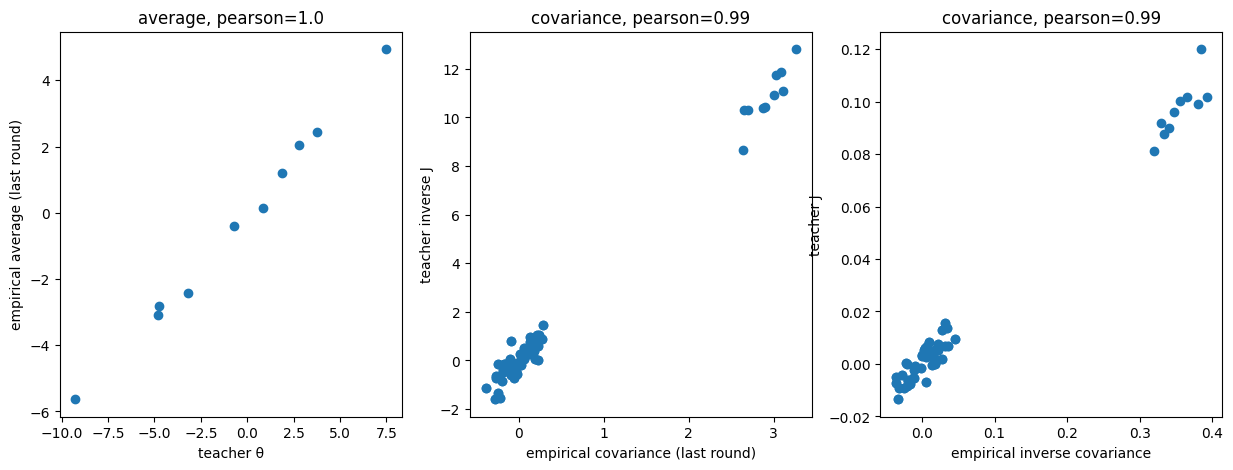

PyObject Text(0.5, 1.0, 'covariance, pearson=0.99')

In [13]:
fig, ax = subplots(1,3,5)
μ_eq = mean(x[:,:,end], dims=2)
Σ_eq = ((x[:,:,end] .- μ_eq)*(x[:,:,end] .- μ_eq)')./nsamples

ax[1].scatter(θ, μ_eq)
ax[1].set_xlabel("teacher θ")
ax[1].set_ylabel("empirical average (last round)")
rho_theta = cor(vec(θ), vec(μ_eq))
ax[1].set_title("average, pearson=$(round(rho_theta, digits=2))")


ax[2].scatter(vec(Σ_eq), vec(inv(J)))
ax[2].set_xlabel("empirical covariance (last round)")
ax[2].set_ylabel("teacher inverse J")
rho_sigma = cor(vec(Σ_eq), vec(inv(J)))
ax[2].set_title("covariance, pearson=$(round(rho_sigma, digits=2))")

ax[3].scatter(vec(inv(Σ_eq)), vec(J))
ax[3].set_xlabel("empirical inverse covariance")
ax[3].set_ylabel("teacher J")
rho_J = cor(vec(inv(Σ_eq)), vec(J))
ax[3].set_title("covariance, pearson=$(round(rho_J, digits=2))")

In [15]:
counts = ones(nsamples, T) ./ nsamples
deltas = fill(1,T)
data = collect_data(x, counts, deltas);

In [23]:
l_values, x_opt, status = learn_gamma_nlopt(data, initialize=T, λ=0.0, prior=0.0, ftol_rel=1e-7)

(-0.24364788185670028, [0.32922954657604914, 0.06384730876642714, 0.28085096788761343, -0.021527461511485612, 0.0020936338756368114, 0.3280628734567513, 0.035147123766970774, -0.014813943778771531, -0.03233895983749948, 0.29610074957458404  …  -4.572298071470465, -4.592853905802014, 2.963828957437987, -9.233404750391887, 7.381763368815965, -3.7332688464689587, 0.7106405862919644, -0.2660453726178858, 3.853294991657533, 0.19028739385712493], :FTOL_REACHED)

In [24]:
J_inferred = de.compute_J(x_opt, data.d);

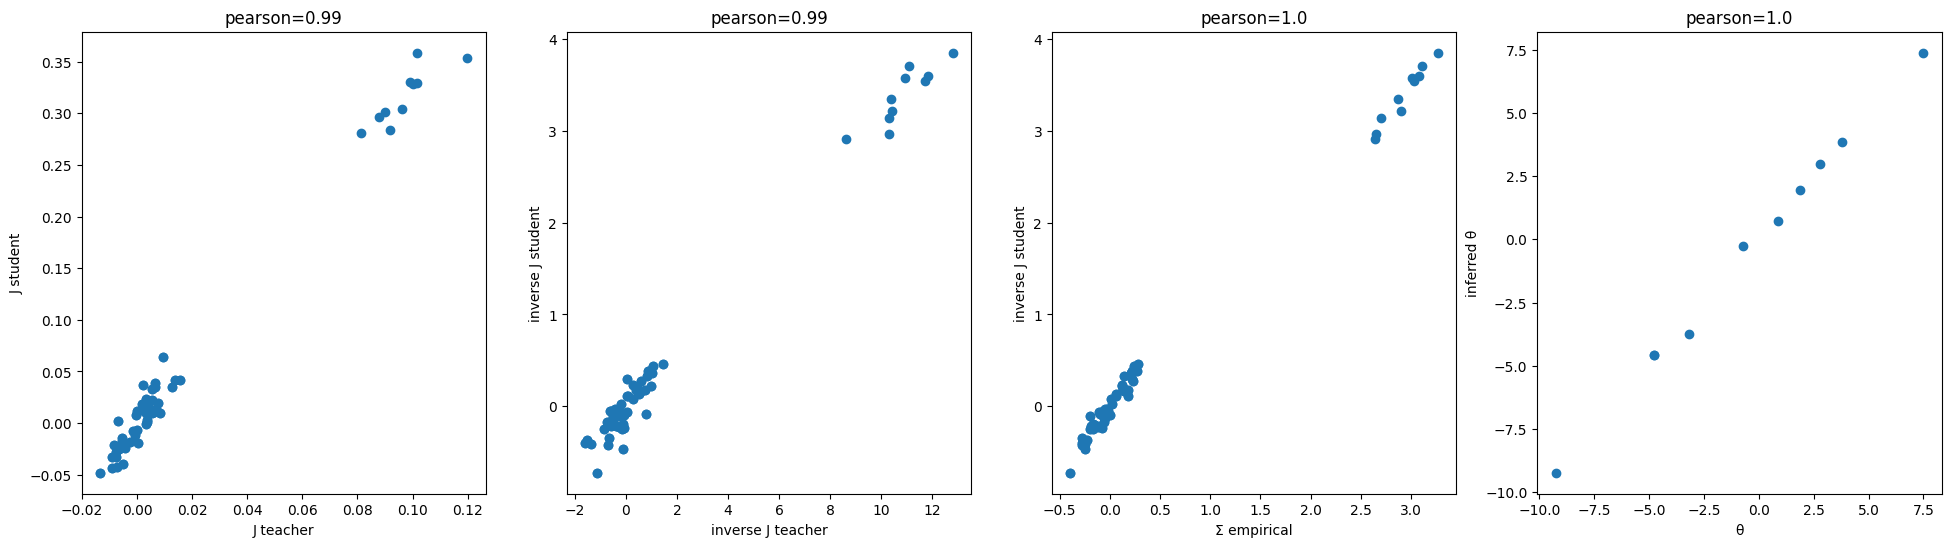

PyObject Text(0.5, 1.0, 'pearson=1.0')

In [25]:
fig, ax = subplots(1, 4, 6)
ax[1].scatter(J, J_inferred)
rho_J = cor(vec(J), vec(J_inferred))
ax[1].set_xlabel("J teacher")
ax[1].set_ylabel("J student")
ax[1].set_title("pearson=$(round(rho_J, digits=2))")

ax[2].scatter(inv(J), inv(J_inferred))
rho_invJ = cor(vec(inv(J)), vec(inv(J_inferred)))
ax[2].set_xlabel("inverse J teacher")
ax[2].set_ylabel("inverse J student")
ax[2].set_title("pearson=$(round(rho_invJ, digits=2))")

ax[3].scatter(Σ_eq, inv(J_inferred))
rho_sigma_invJ = cor(vec(Σ_eq), vec(inv(J_inferred)))
ax[3].set_xlabel("Σ empirical")
ax[3].set_ylabel("inverse J student")
ax[3].set_title("pearson=$(round(rho_sigma_invJ, digits=2))")

ax[4].scatter(θ, x_opt[[de.Hindex(i,data.d) for i in 1:data.d]])
rho_theta = cor(vec(θ), x_opt[[de.Hindex(i,data.d) for i in 1:data.d]])
ax[4].set_xlabel("θ")
ax[4].set_ylabel("inferred θ")
ax[4].set_title("pearson=$(round(rho_theta, digits=2))")

In [26]:
γ = vcat([0.001, 0.005], collect(0.1:0.1:1.5))

17-element Vector{Float64}:
 0.001
 0.005
 0.1
 0.2
 0.3
 0.4
 0.5
 0.6
 0.7
 0.8
 0.9
 1.0
 1.1
 1.2
 1.3
 1.4
 1.5

In [27]:
lγ = map(x->de.log_likelihood(x_opt, data, x, 0.0, 0.00), γ)

17-element Vector{Float64}:
 1803.5081967561223
  327.8487528073441
    2.349004802609444
   -0.2313347294952237
    0.6706420836744365
    2.009533976366411
    3.3591087690725034
    4.633849537734567
    5.820612922180325
    6.924371267190855
    7.954214235618319
    8.919345873866217
    9.827980409003583
   10.687144505719246
   11.50276040848485
   12.279801339162724
   13.022449276040467

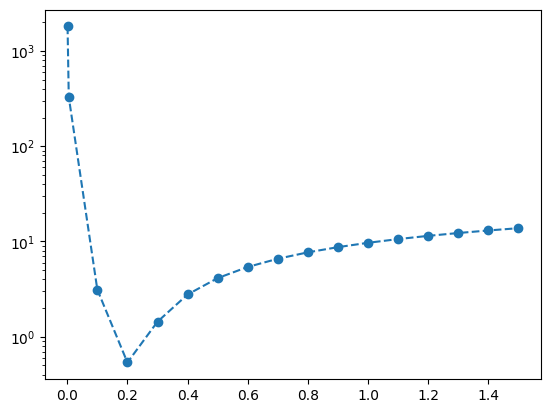

In [31]:
plot(γ, lγ .+ (minimum(lγ) + 1.0), linestyle="dashed", marker="o")
yscale(:log)

In [33]:
grad = zeros(length(x_opt))
de.optim_wrapper_gamma(x_opt, grad, data, 0.0, 0.0)
grad

66-element Vector{Float64}:
 -3.427658896561561e-5
 -9.923311041085559e-5
  0.00018907606486175512
 -8.718544768357081e-5
  7.956008176182626e-5
  7.254507076220364e-6
 -0.0001287269206708217
  0.00014638094325246484
 -9.364764476877188e-6
 -2.1220086763841517e-5
  0.0001328440393022507
  0.00010680221789458304
  0.00012466921015824757
  ⋮
 -0.00011141171551276412
 -5.381810163834858e-5
 -8.15191734658625e-5
  6.996812286591829e-5
  4.896802826732382e-5
  0.00010765452664036182
  5.65343944459869e-5
  2.843780923268951e-5
 -7.314485265709633e-5
 -7.763876276711029e-5
 -2.8670204924124587e-5
 -0.0008906759979817828

In [34]:
extrema(grad)

(-0.0008906759979817828, 0.0002091086165703416)

# using gamma from teacher